# Ropedia Academy — A7 · Motion priors & generation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/A7.ipynb)

> **Runs a full motion-diffusion reverse process and plots the denoising trajectory plus a foot-path with contact frames flagged (the foot-skate failure).**
>
> 跑完整的运动扩散反向过程，画出去噪轨迹，以及标出接触帧的脚部路径（脚滑失败模式）。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/A7

generated motion: (1, 144) conditioned on (1, 16)


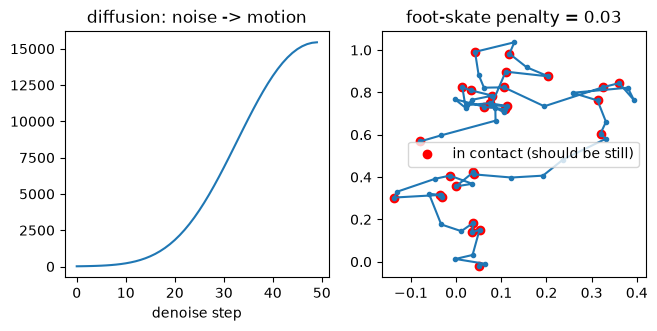

In [1]:
import torch, torch.nn as nn, matplotlib.pyplot as plt
# Motion diffusion: denoise random noise into a (conditioned) motion sample.

# ---------- INPUT: pure noise + a condition embedding + a noise schedule ----------
D = 24*6                                          # 24 joints x 6D rotation
x = torch.randn(1, D)                            # x_T: pure noise
cond = torch.randn(1, 16)                        # text/music embedding
betas = torch.linspace(1e-4, 0.02, 50); abar = torch.cumprod(1 - betas, 0)

# ---------- MODEL: the reverse process iteratively denoises x ----------
denoiser = nn.Sequential(nn.Linear(D + 1 + 16, 256), nn.SiLU(), nn.Linear(256, D))
traj = []
for step in reversed(range(len(betas))):
    tt = torch.full((1,1), step/len(betas))
    eps = denoiser(torch.cat([x, tt, cond], -1))
    x = (x - (1-abar[step]).sqrt()*eps) / abar[step].sqrt()
    traj.append(x.detach().norm().item())
T = 60; foot = torch.cumsum(torch.randn(T,2)*0.05, 0); contact = (torch.rand(T) > 0.5)
skate = ((foot[1:]-foot[:-1]).norm(dim=-1) * contact[1:]).mean()   # plausibility metric

# ---------- OUTPUT: shapes + denoising trajectory + foot-skate diagnosis ----------
print("generated motion:", tuple(x.shape), "conditioned on", tuple(cond.shape))
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.2))
ax[0].plot(traj); ax[0].set_title("diffusion: noise -> motion"); ax[0].set_xlabel("denoise step")
ax[1].plot(foot[:,0], foot[:,1], '-o', ms=3); m = contact.numpy()
ax[1].scatter(foot[m,0], foot[m,1], c='r', label='in contact (should be still)')
ax[1].set_title(f"foot-skate penalty = {skate:.2f}"); ax[1].legend(); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/A7
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks